In [ ]:
import numpy as np
from Solver.AdvReactUni import AdvReactUni1DSolver, AdvReactUni1DEval
from Solver.FVUni2nd import FVUni2nd1D
from Solver.ODE import ESDIRK, DITRExp

Nx = 128 * 1
dt = 1 / Nx / 2 / 1 * 4
dtRef = 1 / Nx / 2 / 4
tEnd = 1

fv = FVUni2nd1D(nx=Nx)
ev = AdvReactUni1DEval(
    fv=fv,
    model="bistable",
    params={"a": 0.5, "k": 1000},
)
solver4 = AdvReactUni1DSolver(eval=ev, ode=ESDIRK("ESDIRK4"))
solver = AdvReactUni1DSolver(eval=ev, ode=ESDIRK("ESDIRK3"))
solverDITR = AdvReactUni1DSolver(eval=ev, ode=DITRExp())

u = np.array([np.sin(fv.xcs * np.pi * 2) * 0.5 + 0.5])

u1_ref = solver4.stepInterval(
    dtRef,
    u,
    0.0,
    tEnd,
    mode="full",
    solve_opts={
        # "max_iter": 50,
        "CFL": 1000,
    },
)

u1_strang = solver.stepInterval(
    dt,
    u,
    0.0,
    tEnd,
    mode="strang",
    solve_opts={
        # "max_iter": 50,
        "CFL": 10,
    },
)

iter [2,3], resN [5.8151e-04 / 1.7722e+02]
iter [3,3], resN [1.2216e-04 / 5.9170e+01]
iter [4,3], resN [2.3665e-04 / 1.0140e+02]
iter [5,3], resN [1.6423e-04 / 8.0170e+01]
iter [6,3], resN [8.8836e-05 / 5.2158e+01]
Step [1], t = [9.7656e-04] uNorm [7.067070100554425]
iter [2,3], resN [5.8928e-04 / 1.7059e+02]
iter [3,3], resN [9.4748e-05 / 5.6807e+01]
iter [4,3], resN [2.2327e-04 / 9.7252e+01]
iter [5,3], resN [1.5632e-04 / 7.6585e+01]
iter [6,3], resN [8.0402e-05 / 4.9672e+01]
Step [2], t = [1.9531e-03] uNorm [7.199335963510122]
iter [2,3], resN [7.1627e-04 / 1.6171e+02]
iter [3,3], resN [8.7146e-05 / 5.3724e+01]
iter [4,3], resN [2.7896e-04 / 9.1887e+01]
iter [5,3], resN [2.0354e-04 / 7.2103e+01]
iter [6,3], resN [1.0735e-04 / 4.6632e+01]
Step [3], t = [2.9297e-03] uNorm [7.321935435252049]
iter [2,3], resN [9.4357e-04 / 1.5121e+02]
iter [3,3], resN [1.0795e-04 / 5.0137e+01]
iter [4,3], resN [3.8505e-04 / 8.5682e+01]
iter [5,3], resN [2.9927e-04 / 6.7033e+01]
iter [6,3], resN [1.7031

In [2]:
u1 = solver.stepInterval(
    dt,
    u,
    0.0,
    tEnd,
    solve_opts={
        "rel_tol": 1e-4,
        "CFL": 10,
    },
)


iter [2,5], resN [8.7940e-03 / 3.0898e+02]
iter [3,5], resN [3.0306e-03 / 8.7852e+01]
iter [4,5], resN [3.6555e-03 / 1.3982e+02]
Step [1], t = [3.9062e-03] uNorm [7.433185779574135]
iter [2,5], resN [2.3129e-02 / 2.4462e+02]
iter [3,6], resN [1.0762e-03 / 6.6332e+01]
iter [4,6], resN [2.0376e-03 / 1.0270e+02]
Step [2], t = [7.8125e-03] uNorm [7.750221799291288]
iter [2,6], resN [5.9865e-03 / 1.6910e+02]
iter [3,6], resN [1.5941e-03 / 4.5226e+01]
iter [4,7], resN [5.9869e-03 / 7.1891e+01]
Step [3], t = [1.1719e-02] uNorm [7.899469400779943]
iter [2,8], resN [6.9277e-03 / 1.1963e+02]
iter [3,9], resN [1.1463e-03 / 3.3795e+01]
iter [4,9], resN [2.0081e-03 / 5.4620e+01]
Step [4], t = [1.5625e-02] uNorm [7.952486996374133]
iter [2,6], resN [6.4959e-03 / 1.2793e+02]
iter [3,7], resN [1.2496e-03 / 3.2396e+01]
iter [4,7], resN [4.0239e-03 / 4.8283e+01]
Step [5], t = [1.9531e-02] uNorm [7.96556176556721]
iter [2,8], resN [7.8241e-03 / 9.5715e+01]
iter [3,8], resN [1.4248e-03 / 3.4301e+01]
iter 

In [3]:
u1Ditr = None
u1Ditr = solverDITR.stepInterval(
    dt,
    u,
    0.0,
    tEnd,
    solve_opts={
        "rel_tol": 1e-4,
        "CFL": 10,
    },
    use_exp=False,
)

iter [[0.5, 1],6], resN [8.1948e-03 / 3.4221e+02]
Step [1], t = [3.9062e-03] uNorm [7.433538004495629]
iter [[0.5, 1],6], resN [9.3368e-03 / 2.5409e+02]
Step [2], t = [7.8125e-03] uNorm [7.747985009240537]
iter [[0.5, 1],6], resN [1.5314e-02 / 1.7206e+02]
Step [3], t = [1.1719e-02] uNorm [7.896417953536928]
iter [[0.5, 1],9], resN [6.5956e-03 / 1.2807e+02]
Step [4], t = [1.5625e-02] uNorm [7.95238527463111]
iter [[0.5, 1],6], resN [8.2401e-03 / 1.1083e+02]
Step [5], t = [1.9531e-02] uNorm [7.962765916627507]
iter [[0.5, 1],9], resN [7.3227e-03 / 1.3712e+02]
Step [6], t = [2.3438e-02] uNorm [7.968414476254951]
iter [[0.5, 1],8], resN [3.9093e-03 / 1.0620e+02]
Step [7], t = [2.7344e-02] uNorm [7.967169423973319]
iter [[0.5, 1],9], resN [5.0232e-03 / 1.2440e+02]
Step [8], t = [3.1250e-02] uNorm [7.966754239024656]
iter [[0.5, 1],8], resN [1.2581e-02 / 1.3214e+02]
Step [9], t = [3.5156e-02] uNorm [7.969186111166959]
iter [[0.5, 1],8], resN [9.9054e-03 / 1.0923e+02]
Step [10], t = [3.9062e-

In [4]:
u1DitrExp = solverDITR.stepInterval(
    dt,
    u,
    0.0,
    tEnd,
    solve_opts={
        "rel_tol": 1e-4,
        "CFL": 10,
        "max_iter": 50,
    },
    use_exp=True,
)

iter [[0.5, 1],6], resN [7.9611e-03 / 3.3155e+02]
Step [1], t = [3.9062e-03] uNorm [7.4338227970186965]
iter [[0.5, 1],6], resN [9.1053e-03 / 2.4178e+02]
Step [2], t = [7.8125e-03] uNorm [7.7484091251229925]
iter [[0.5, 1],6], resN [1.4727e-02 / 1.6297e+02]
Step [3], t = [1.1719e-02] uNorm [7.896774377967534]
iter [[0.5, 1],8], resN [4.9850e-03 / 1.2303e+02]
Step [4], t = [1.5625e-02] uNorm [7.952599639309425]
iter [[0.5, 1],6], resN [4.1641e-03 / 1.0719e+02]
Step [5], t = [1.9531e-02] uNorm [7.962845374366531]
iter [[0.5, 1],8], resN [4.1963e-03 / 1.3614e+02]
Step [6], t = [2.3438e-02] uNorm [7.968439772146769]
iter [[0.5, 1],7], resN [6.4290e-03 / 9.7625e+01]
Step [7], t = [2.7344e-02] uNorm [7.967122604042728]
iter [[0.5, 1],8], resN [3.2237e-03 / 1.2352e+02]
Step [8], t = [3.1250e-02] uNorm [7.966769086142424]
iter [[0.5, 1],8], resN [2.9008e-03 / 1.2961e+02]
Step [9], t = [3.5156e-02] uNorm [7.969148338369556]
iter [[0.5, 1],7], resN [8.3728e-03 / 1.0855e+02]
Step [10], t = [3.906

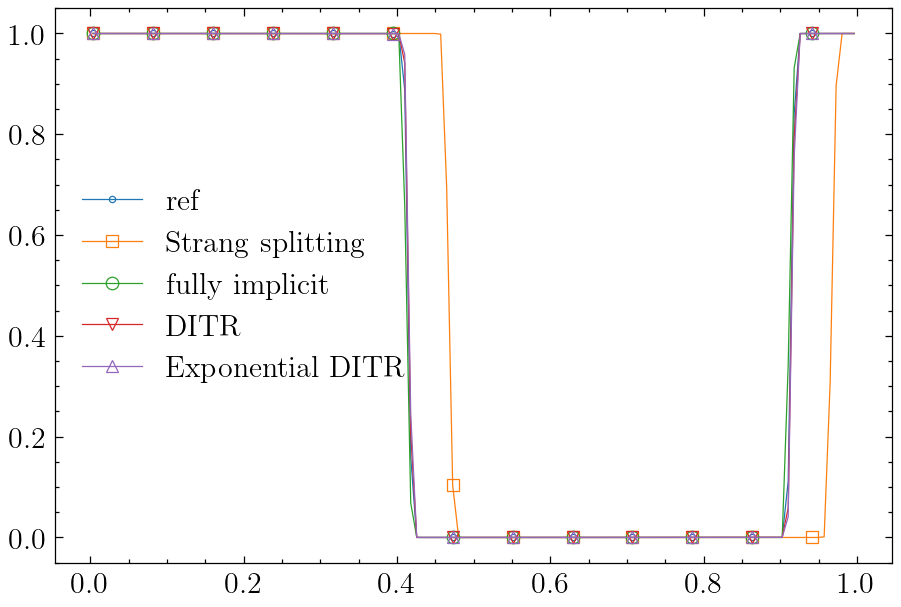

In [5]:
import matplotlib.pyplot as plt
import PlotEnv

plotEnv = PlotEnv.PlotEnv(dpi=180, markEvery=10)

fig = plotEnv.figure(101, figsize=(6, 4))
plotEnv.plot(fv.xcs, u1_ref[0], plotIndex=0, label = "ref")
plotEnv.plot(fv.xcs, u1_strang[0], plotIndex=1, label="Strang splitting")
plotEnv.plot(fv.xcs, u1[0], plotIndex=2, label="fully implicit")
plotEnv.plot(fv.xcs, u1Ditr[0], plotIndex=3, label="DITR")
plotEnv.plot(fv.xcs, u1DitrExp[0], plotIndex=4, label="Exponential DITR")
plt.legend()
plt.show()